Evaluación Final mod.3
-----------------------------------------------FACE 2: ANÁLISIS ESTADÍSTICO---------------------------------------------------------

In [29]:
import pandas as pd #hago las importaciones de librerias.
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
import warnings # para que no se imprimam los future warning
warnings.filterwarnings('ignore', category=FutureWarning)

In [31]:
pd.set_option('display.max_columns', None) # para que se muestren todas las columnas del dataframe al imprimirlo.

In [32]:
df_limpio = pd.read_csv("files/df_nuevo.csv") # cargo el nuevo dataframe que he creado en la face 1 para no tener que hacer el merge cada vez que quiera trabajar con el dataframe limpio.

In [33]:
df_limpio.head(5) # imprimo las primeras filas del nuevo dataframe para comprobar que se ha cargado correctamente y para tener una idea de como es el dataframe limpio.

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN
1,100102,2017,1,10,4,14,2030,203.0,0,0,Ontario,Toronto,M1R 4K3,Male,College,73479,Single,Nova,2887.74,Standard,2013,3,NaN,NaN
2,100140,2017,1,6,0,6,1200,120.0,0,0,British Columbia,Dawson Creek,U5I 4F1,Female,College,73479,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN
3,100214,2017,1,0,0,0,0,0.0,0,0,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253,Married,Star,4170.57,Standard,2015,8,NaN,NaN
4,100272,2017,1,0,0,0,0,0.0,0,0,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN


In [34]:
df_limpio.shape # compruebo el numero de filas y columnas del nuevo dataframe para tener una idea de su tamaño.

(403760, 24)

In [45]:
df_limpio # busco si hay filas duplicadas para eliminarlas si las hay, ya que no aportan información relevante y pueden cambiar los resultados.

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN
1,100102,2017,1,10,4,14,2030,203.0,0,0,Ontario,Toronto,M1R 4K3,Male,College,73479,Single,Nova,2887.74,Standard,2013,3,NaN,NaN
2,100140,2017,1,6,0,6,1200,120.0,0,0,British Columbia,Dawson Creek,U5I 4F1,Female,College,73479,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN
3,100214,2017,1,0,0,0,0,0.0,0,0,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253,Married,Star,4170.57,Standard,2015,8,NaN,NaN
4,100272,2017,1,0,0,0,0,0.0,0,0,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403755,999902,2018,12,0,0,0,0,0.0,0,0,Ontario,Toronto,M1R 4K3,Male,College,73479,Married,Aurora,7290.07,Standard,2014,5,NaN,NaN
403756,999911,2018,12,0,0,0,0,0.0,0,0,Newfoundland,St. John's,A1C 6H9,Male,Doctor,217943,Single,Nova,8564.77,Standard,2012,8,NaN,NaN
403757,999940,2018,12,3,0,3,1233,123.0,0,0,Quebec,Quebec City,G1B 3L5,Female,Bachelor,47670,Married,Nova,20266.50,Standard,2017,7,NaN,NaN
403758,999982,2018,12,0,0,0,0,0.0,0,0,British Columbia,Victoria,V10 6T5,Male,College,73479,Married,Star,2631.56,Standard,2018,7,NaN,NaN


In [37]:
df_limpio.duplicated().sum() # busco si hay filas duplicadas eliminarlas si las hay, ya que no aportan información relevante y pueden sesgar los resultados.

np.int64(0)

In [46]:
df_limpio.isna().sum() # busco si hay valores nulos para eliminarlos o imputarlos si los hay, ya que no aportan información relevante y pueden cambiar los resultados.

loyalty_number                      0
year                                0
month                               0
flights_booked                      0
flights_with_companions             0
total_flights                       0
distance                            0
points_accumulated                  0
points_redeemed                     0
dollar_cost_points_redeemed         0
province                            0
city                                0
postal_code                         0
gender                              0
education                           0
salary                              0
marital_status                      0
loyalty_card                        0
clv                                 0
enrollment_type                     0
enrollment_year                     0
enrollment_month                    0
cancellation_year              354110
cancellation_month             354110
dtype: int64

In [47]:
df_limpio.info() # imprimo la información para tener una idea de los tipos de datos que tengo y poder elegir cuales quiero analizar.

<class 'pandas.DataFrame'>
RangeIndex: 403760 entries, 0 to 403759
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loyalty_number               403760 non-null  int64  
 1   year                         403760 non-null  int64  
 2   month                        403760 non-null  int64  
 3   flights_booked               403760 non-null  int64  
 4   flights_with_companions      403760 non-null  int64  
 5   total_flights                403760 non-null  int64  
 6   distance                     403760 non-null  int64  
 7   points_accumulated           403760 non-null  float64
 8   points_redeemed              403760 non-null  int64  
 9   dollar_cost_points_redeemed  403760 non-null  int64  
 10  province                     403760 non-null  str    
 11  city                         403760 non-null  str    
 12  postal_code                  403760 non-null  str    
 13  gender    

In [48]:
df_limpio.describe().T.round(2) # imprimo la descripción estadística de las columnas numéricas para tener una idea de la distribución de los datos y redondeo a 2 decimales para que se vea mejor.

,count,mean,std,min,25%,50%,75%,max
loyalty_number,403760.0,549875.38,258961.51,100018.00,326699.00,550598.00,772152.00,999986.00
year,403760.0,2017.50,0.50,2017.00,2017.00,2018.00,2018.00,2018.00
month,403760.0,6.50,3.45,1.00,4.00,7.00,10.00,12.00
flights_booked,403760.0,4.13,5.23,0.00,0.00,1.00,8.00,21.00
flights_with_companions,403760.0,1.04,2.08,0.00,0.00,0.00,1.00,11.00
total_flights,403760.0,5.17,6.53,0.00,0.00,1.00,10.00,32.00
distance,403760.0,1214.46,1434.10,0.00,0.00,525.00,2342.00,6293.00
points_accumulated,403760.0,124.26,146.70,0.00,0.00,53.00,240.00,676.50
points_redeemed,403760.0,30.84,125.76,0.00,0.00,0.00,0.00,876.00
dollar_cost_points_redeemed,403760.0,2.50,10.17,0.00,0.00,0.00,0.00,71.00


<Axes: xlabel='salary', ylabel='education'>

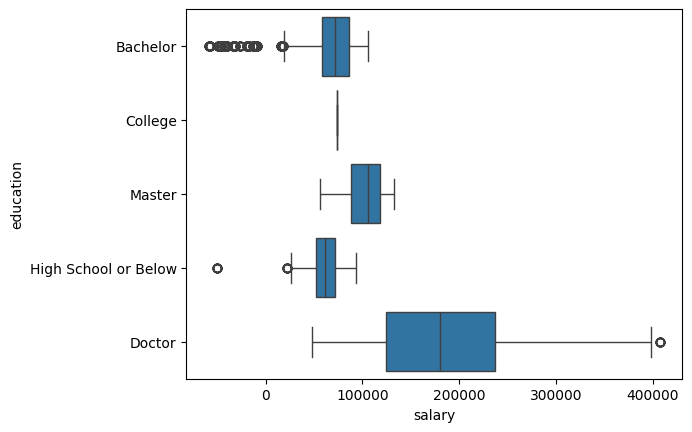

In [49]:
sns.boxplot(data=df_limpio, x='salary', y='education') # creo un boxplot para ver la distribución del salario en función de la educación, ya que quiero ver si hay diferencias significativas entre los salarios de las personas con diferentes niveles educativos.